In [11]:
#Import useful libraries
#Import pandas for loading and exploring tabular data
import pandas as pd

#Import numpy for basic numerical operations
import numpy as np

#Import matplot for plotting
import matplotlib.pyplot as plt

#Import seaborn for statistical visualisations
import seaborn as sns

#Enable inline plotting so figures appear in the notebook
%matplotlib inline

In [12]:
#Load datset 2 from CSV into a pandas DataFrame
dataset2 = pd.read_csv('credit_dataset2.csv')

#Show first 5 rows
print("First 5 rows of the dataset:")
print(dataset2.head())

First 5 rows of the dataset:
      CUST_ID  INCOME  SAVINGS     DEBT  R_SAVINGS_INCOME  R_DEBT_INCOME  \
0  C02COQEVYU   33269        0   532304            0.0000        16.0000   
1  C02OZKC0ZF   77158    91187   315648            1.1818         4.0909   
2  C03FHP2D0A   30917    21642   534864            0.7000        17.3000   
3  C03PVPPHOY   80657    64526   629125            0.8000         7.8000   
4  C04J69MUX0  149971  1172498  2399531            7.8182        16.0000   

   R_DEBT_SAVINGS  T_CLOTHING_12  R_CLOTHING  R_CLOTHING_INCOME  ...  \
0          1.2000           1889      0.5003             0.0568  ...   
1          3.4615           5818      0.0191             0.0754  ...   
2         24.7142           1157      0.7433             0.0374  ...   
3          9.7499           6857      0.5376             0.0850  ...   
4          2.0465           1978      0.1628             0.0132  ...   

   R_UTILITIES_SAVINGS  R_UTILITIES_DEBT  T_EXPENDITURE_12  R_EXPENDITURE  \
0   

In [13]:
#Remove customer id
dataset2 = dataset2.drop(columns='CUST_ID')

#Check the dataset after removal
print(dataset2.shape)
print('CUST_ID' in dataset2.columns)

(1000, 69)
False


In [15]:
#Check target variable is there
print('DEFAULT' in dataset2.columns)

True


In [23]:
#Separate features (independent variables) and target (dependent variable)
#Drop the 'DEFAULT' column (target)

#Feature matrix without target
X = dataset2.drop (["DEFAULT"], axis = 1)

#Target vector is DEFAULT
y = dataset2 ["DEFAULT"]

#Import train_test_split data into training and test sets
from sklearn.model_selection import train_test_split

#Split the dataset into training and test sets
#Use 20% of samples for testing by doing test_size=0.2
#random_state is set for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42

)

#Print the shapes of the resulting arrays to confirm the split
print("\nShape of X_train.shape:", X_train.shape)
print("\nShape of X_test.shape:", X_test.shape)
print("\nShape of y_train.shape:", y_train.shape)
print("\nShape of y_test.shape:", y_test.shape)



Shape of X_train.shape: (800, 68)

Shape of X_test.shape: (200, 68)

Shape of y_train.shape: (800,)

Shape of y_test.shape: (200,)


Next Logistic Regression

In [24]:
#Import Logistic Regression libraries
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Use standard scaler to transform data as target variable is imbalanced
logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
    max_iter = 200,
    class_weight = 'balanced'
    ))
])

#Train the model
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](68,)","['INCOME','SAVINGS','DEBT',...,'R_EXPENDITURE_DEBT','CAT_CREDIT_CARD', 'CAT_DEPENDENTS']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,68
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Next make random forest model

In [21]:
#Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

#Create Random Forest Classifier
#Initialise random forest
rf_class = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    class_weight = "balanced"
)

#Train Random Forest model
rf_class.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

Step 5 - Evaluation

Logistic Regression Accuracy: 0.560
Random Forest Accuracy: 0.635

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.55      0.65       146
           1       0.32      0.57      0.41        54

    accuracy                           0.56       200
   macro avg       0.55      0.56      0.53       200
weighted avg       0.66      0.56      0.58       200

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       146
           1       0.31      0.30      0.30        54

    accuracy                           0.64       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.63      0.64      0.63       200



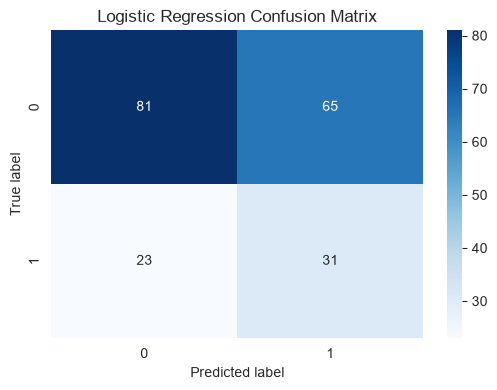

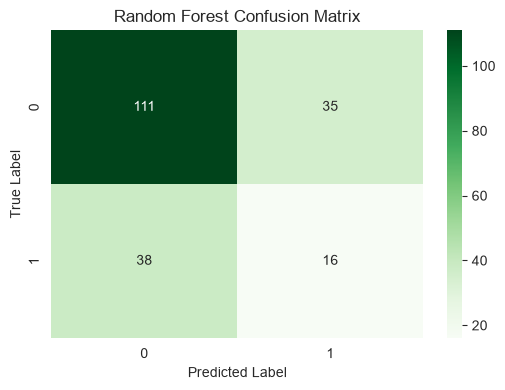

In [25]:
#Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#-------------------------------
#Predictions for each model
#-------------------------------


#Make predictions using logistic regression model
y_pred_logistic = logistic_model.predict(X_test)

#Predict using Random Forest Classifier
y_pred_rf = rf_class.predict(X_test)

#-------------------------------
#Accuracy scores
#-------------------------------
#Accuracy for Logistic Regression
acc_log = accuracy_score(y_test, y_pred_logistic)

#Accuracy for Random Forest Classifier
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression Accuracy: {acc_log:.3f}")
print(f"Random Forest Accuracy: {acc_rf:.3f}")

#-------------------------------
#Classification Reports
#-------------------------------
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

#-------------------------------
#Confusion Matrices
#-------------------------------
#Confusion matrix for Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_logistic)

#Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

#-------------------------------
#Plot Confusion Matrix for  Logistic Regression
#-------------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True,fmt="d",cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

#-------------------------------
#Plot Confusion Matrix for Random Forest
#-------------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [26]:
#Import roc_auc evaluation metrics
from sklearn.metrics import roc_auc_score

#Predict probability for logistic regression
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

#ROC-AUC scores for logistic regression
auc_log = roc_auc_score(y_test, y_prob_log)

#Predict probability for random forest
y_prob_rf = rf_class.predict_proba(X_test)[:, 1]

#ROC-AUC scores for random forest
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Logistic Regression AUC Score: {auc_log:.3f}")
print(f"Random Forest AUC Score: {auc_rf:.3f}")

Logistic Regression AUC Score: 0.615
Random Forest AUC Score: 0.602
